In [ ]:
# =============================================================================
# SECTION 1: LOAD DATA  (ROBUST VERSION)
# =============================================================================

import csv
import os
import pandas as pd


DATA_PATH = "/content/OP322 review_20252026_standard.csv"

if not os.path.exists(DATA_PATH):
    candidates = [f for f in os.listdir('.') if f.endswith('.csv')]
    if candidates:
        DATA_PATH = candidates[0]
        print(f"Using dataset: {DATA_PATH}")
    else:
        raise FileNotFoundError(
            "Dataset not found. Place the CSV at: "
            "/content/OP322 review_20252026_standard.csv"
        )

print("\nLoading dataset safely...")

try:
    # ── Attempt 1: Standard parser ─────────────────────────────────────
    df = pd.read_csv(DATA_PATH)

except Exception as e1:

    print("\nStandard parser failed:")
    print(e1)

    try:
        # ── Attempt 2: Python engine (more tolerant) ──────────────────
        df = pd.read_csv(
            DATA_PATH,
            engine='python',
            quoting=csv.QUOTE_MINIMAL,
            on_bad_lines='skip'
        )

        print("\nLoaded using Python engine with bad lines skipped.")

    except Exception as e2:

        print("\nPython engine also failed:")
        print(e2)

        # ── Attempt 3: Disable quote parsing completely ───────────────
        df = pd.read_csv(
            DATA_PATH,
            engine='python',
            sep=',',
            quoting=csv.QUOTE_NONE,
            on_bad_lines='skip',
            encoding='utf-8',
            encoding_errors='ignore'
        )

        print("\nLoaded with QUOTE_NONE fallback.")

# ── Basic validation ────────────────────────────────────────────────────────

expected_cols = ['id', 'sentiment', 'review']

missing_cols = [c for c in expected_cols if c not in df.columns]

if missing_cols:
    raise ValueError(
        f"Missing required columns: {missing_cols}\n"
        f"Columns found: {df.columns.tolist()}"
    )

# ── Remove completely empty rows ────────────────────────────────────────────
df = df.dropna(subset=['review', 'sentiment'])

# ── Ensure correct datatypes ────────────────────────────────────────────────
df['review'] = df['review'].astype(str)
df['sentiment'] = pd.to_numeric(df['sentiment'], errors='coerce')

# remove invalid labels
df = df[df['sentiment'].isin([0, 1])]

df['sentiment'] = df['sentiment'].astype(int)

print(f"\nDataset shape     : {df.shape}")
print(f"Columns           : {df.columns.tolist()}")

print("\nMissing values:")
print(df.isnull().sum())

print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

print("\nSample review:")
print(df['review'].iloc[0][:300], "...")


Loading dataset safely...

Standard parser failed:
Error tokenizing data. C error: EOF inside string starting at row 14886

Loaded using Python engine with bad lines skipped.

Dataset shape     : (14885, 3)
Columns           : ['id', 'sentiment', 'review']

Missing values:
id           0
sentiment    0
review       0
dtype: int64

Sentiment distribution:
sentiment
0    7444
1    7441
Name: count, dtype: int64

Sample review:
"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe m ...


MANG3098 Sentiment Analysis — Student ID: 33414882
TensorFlow version : 2.20.0

Loading dataset safely...

Standard parser failed:
Error tokenizing data. C error: EOF inside string starting at row 14886

Loaded using Python engine with bad lines skipped.

Dataset shape     : (14885, 3)
Columns           : ['id', 'sentiment', 'review']

Missing values:
id           0
sentiment    0
review       0
dtype: int64

Sentiment distribution:
sentiment
0    7444
1    7441
Name: count, dtype: int64

Sample review:
"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe m ...

── Review Length Statistics ──
count    14885.00
mean       232.95
std        174.37
min         12.00
25%        126.00
50%        173.00
75%        282.00
max       2460.00
Name: word

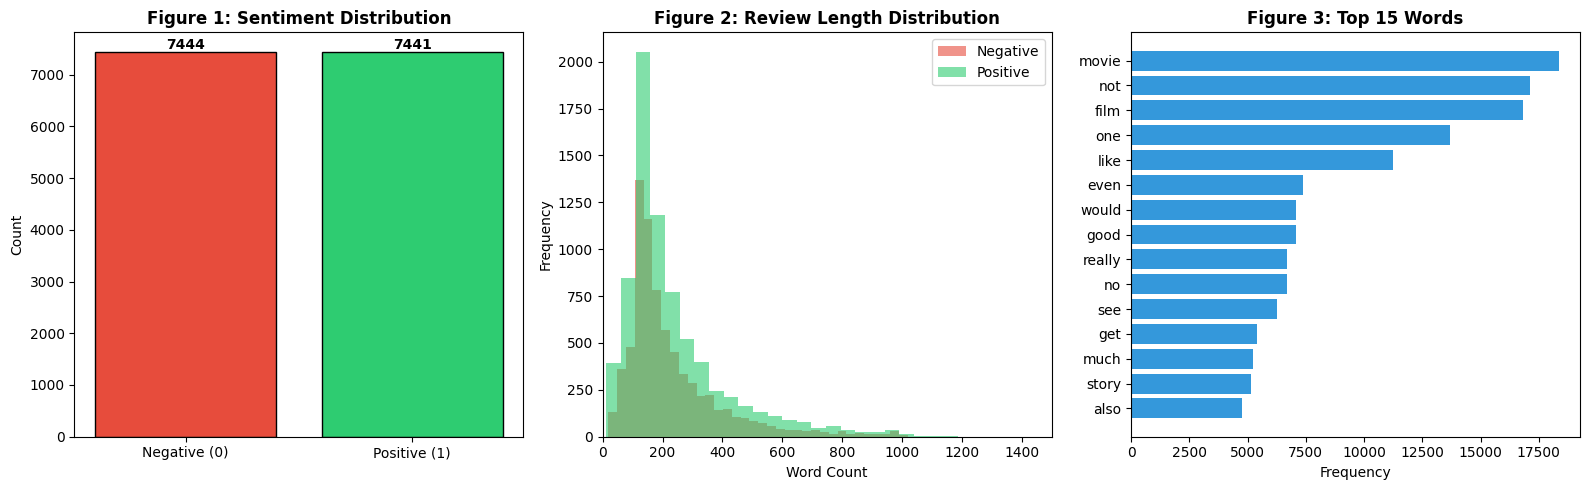


Preprocessing reviews...

── Processed Review Statistics ──
count    14885.00
mean       120.87
std         91.90
min          7.00
25%         64.00
50%         89.00
75%        147.00
max       1397.00
Name: processed_word_count, dtype: float64

Top 20 words after preprocessing:
  movie               : 30108
  film                : 27863
  not                 : 18764
  one                 : 16207
  like                : 12016
  time                : 9201
  good                : 8743
  character           : 8437
  even                : 7597
  story               : 7531
  get                 : 7515
  would               : 7151
  see                 : 7105
  make                : 7088
  really              : 7072
  scene               : 6258
  much                : 5782
  well                : 5710
  people              : 5611
  bad                 : 5461

Split sizes:
Train : 10419
Val   : 2233
Test  : 2233

Vocabulary size : 30,000
Train shape : (10419, 300)
Val shape   : (2233, 300)

In [ ]:
"""
MANG3098 - Analytics in Action II
Individual Coursework 2 - Movie Review Sentiment Analysis
Student ID: 33414882 | Random Seed: 33414882
"""

# =============================================================================
# SECTION 0: IMPORTS & SETUP
# =============================================================================

import os
import re
import csv
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    ConfusionMatrixDisplay
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    GRU,
    Dense,
    Dropout,
    Bidirectional,
    Conv1D,
    BatchNormalization,
    SpatialDropout1D
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')

# =============================================================================
# REPRODUCIBILITY
# =============================================================================

SEED = 33414882

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# =============================================================================
# NLTK DOWNLOADS
# =============================================================================

for pkg in [
    'punkt',
    'stopwords',
    'wordnet',
    'omw-1.4',
    'punkt_tab',
    'averaged_perceptron_tagger'
]:
    nltk.download(pkg, quiet=True)

print("=" * 60)
print("MANG3098 Sentiment Analysis — Student ID: 33414882")
print(f"TensorFlow version : {tf.__version__}")
print("=" * 60)

# =============================================================================
# SECTION 1: LOAD DATA (ROBUST CSV LOADING)
# =============================================================================

DATA_PATH = "/content/OP322 review_20252026_standard.csv"

if not os.path.exists(DATA_PATH):

    candidates = [
        f for f in os.listdir('.')
        if f.endswith('.csv')
    ]

    if candidates:
        DATA_PATH = candidates[0]
        print(f"Using dataset: {DATA_PATH}")

    else:
        raise FileNotFoundError(
            "Dataset not found. Place the CSV at:\n"
            "/content/OP322 review_20252026_standard.csv"
        )

print("\nLoading dataset safely...")

try:

    df = pd.read_csv(DATA_PATH)

except Exception as e1:

    print("\nStandard parser failed:")
    print(e1)

    try:

        df = pd.read_csv(
            DATA_PATH,
            engine='python',
            quoting=csv.QUOTE_MINIMAL,
            on_bad_lines='skip'
        )

        print("\nLoaded using Python engine with bad lines skipped.")

    except Exception as e2:

        print("\nPython engine also failed:")
        print(e2)

        df = pd.read_csv(
            DATA_PATH,
            engine='python',
            sep=',',
            quoting=csv.QUOTE_NONE,
            on_bad_lines='skip',
            encoding='utf-8',
            encoding_errors='ignore'
        )

        print("\nLoaded with QUOTE_NONE fallback.")

# =============================================================================
# DATA CLEANING
# =============================================================================

expected_cols = ['id', 'sentiment', 'review']

missing_cols = [
    c for c in expected_cols
    if c not in df.columns
]

if missing_cols:

    raise ValueError(
        f"Missing required columns: {missing_cols}\n"
        f"Columns found: {df.columns.tolist()}"
    )

df = df.dropna(subset=['review', 'sentiment'])

df['review'] = df['review'].astype(str)

df['sentiment'] = pd.to_numeric(
    df['sentiment'],
    errors='coerce'
)

df = df[df['sentiment'].isin([0, 1])]

df['sentiment'] = df['sentiment'].astype(int)

df = df.reset_index(drop=True)

print(f"\nDataset shape     : {df.shape}")
print(f"Columns           : {df.columns.tolist()}")

print("\nMissing values:")
print(df.isnull().sum())

print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

print("\nSample review:")
print(df['review'].iloc[0][:300], "...")

# =============================================================================
# SECTION 2: DESCRIPTIVE STATISTICS & EDA
# =============================================================================

# =============================================================================
# Remove HTML
# =============================================================================

df['review_clean_html'] = df['review'].apply(
    lambda x: re.sub(r'<.*?>', ' ', str(x))
)

# =============================================================================
# Review Length
# =============================================================================

df['word_count'] = df['review_clean_html'].apply(
    lambda x: len(x.split())
)

print("\n── Review Length Statistics ──")
print(df['word_count'].describe().round(2))

print(f"\nMedian word count : {df['word_count'].median():.0f}")

print("\n── Word Count by Sentiment ──")

print(
    df.groupby('sentiment')['word_count']
    .describe()
    .round(2)
)

# =============================================================================
# STOPWORDS WITH NEGATION PRESERVED
# =============================================================================

stop_words_set = set(stopwords.words('english'))

negation_words = {
    'not',
    'no',
    'nor',
    'never',
    "don't",
    "didn't",
    "won't",
    "isn't",
    "wasn't",
    "aren't",
    "couldn't",
    "shouldn't"
}

stop_words_set = stop_words_set - negation_words

# =============================================================================
# Most Frequent Words
# =============================================================================

all_words = ' '.join(
    df['review_clean_html'].str.lower()
).split()

raw_freq = Counter(all_words)

print("\nTop 20 most frequent words (raw):")

for w, c in raw_freq.most_common(20):
    print(f"  {w:20s}: {c}")

filtered_words = [
    w for w in all_words
    if w.isalpha() and w not in stop_words_set
]

filtered_freq = Counter(filtered_words)

print("\nTop 20 words (stopwords removed):")

for w, c in filtered_freq.most_common(20):
    print(f"  {w:20s}: {c}")

# =============================================================================
# EDA FIGURES (DISPLAYED)
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# =============================================================================
# Figure 1: Sentiment Distribution
# =============================================================================

sc = df['sentiment'].value_counts()

axes[0].bar(
    ['Negative (0)', 'Positive (1)'],
    [sc[0], sc[1]],
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black'
)

axes[0].set_title(
    'Figure 1: Sentiment Distribution',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_ylabel('Count')

for i, v in enumerate([sc[0], sc[1]]):

    axes[0].text(
        i,
        v + 50,
        str(v),
        ha='center',
        fontweight='bold'
    )

# =============================================================================
# Figure 2: Review Length Distribution
# =============================================================================

for sent, col in [(0, '#e74c3c'), (1, '#2ecc71')]:

    label = 'Negative' if sent == 0 else 'Positive'

    axes[1].hist(
        df[df['sentiment'] == sent]['word_count'],
        bins=50,
        alpha=0.6,
        color=col,
        label=label
    )

axes[1].set_title(
    'Figure 2: Review Length Distribution',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 1500)

# =============================================================================
# Figure 3: Top 15 Words
# =============================================================================

top15 = dict(filtered_freq.most_common(15))

axes[2].barh(
    list(top15.keys())[::-1],
    list(top15.values())[::-1],
    color='#3498db'
)

axes[2].set_title(
    'Figure 3: Top 15 Words',
    fontsize=12,
    fontweight='bold'
)

axes[2].set_xlabel('Frequency')

plt.tight_layout()

# SHOW FIGURES IN NOTEBOOK
plt.show()

# =============================================================================
# SECTION 3: TEXT PREPROCESSING
# =============================================================================

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    """
    Full preprocessing pipeline:
      1. Remove HTML tags
      2. Remove URLs
      3. Lowercase
      4. Remove punctuation/numbers
      5. Tokenise
      6. Remove stopwords
      7. Preserve negation words
      8. Lemmatise
    """

    # Remove HTML
    text = re.sub(r'<.*?>', ' ', str(text))

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Lowercase
    text = text.lower()

    # Remove punctuation/numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [
        t for t in tokens
        if t not in stop_words_set and len(t) > 2
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
    ]

    return ' '.join(tokens)

print("\nPreprocessing reviews...")

df['review_processed'] = df['review_clean_html'].apply(
    preprocess_text
)

df['processed_word_count'] = df['review_processed'].apply(
    lambda x: len(x.split())
)

print("\n── Processed Review Statistics ──")

print(
    df['processed_word_count']
    .describe()
    .round(2)
)

proc_words = ' '.join(df['review_processed']).split()

proc_freq = Counter(proc_words)

print("\nTop 20 words after preprocessing:")

for w, c in proc_freq.most_common(20):
    print(f"  {w:20s}: {c}")

# =============================================================================
# SECTION 4: TRAIN / VALIDATION / TEST SPLIT
# =============================================================================

X = df['review_processed'].values
y = df['sentiment'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print(f"\nSplit sizes:")
print(f"Train : {len(X_train)}")
print(f"Val   : {len(X_val)}")
print(f"Test  : {len(X_test)}")

# =============================================================================
# SECTION 5: TOKENISATION & PADDING
# =============================================================================

MAX_VOCAB = 30000
MAX_LEN = 300
EMBED_DIM = 100

tokenizer_obj = Tokenizer(
    num_words=MAX_VOCAB,
    oov_token='<OOV>'
)

tokenizer_obj.fit_on_texts(X_train)

def texts_to_padded(texts):

    seqs = tokenizer_obj.texts_to_sequences(texts)

    return pad_sequences(
        seqs,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

X_train_seq = texts_to_padded(X_train)
X_val_seq = texts_to_padded(X_val)
X_test_seq = texts_to_padded(X_test)

vocab_size = min(
    MAX_VOCAB,
    len(tokenizer_obj.word_index) + 1
)

print(f"\nVocabulary size : {vocab_size:,}")

print(f"Train shape : {X_train_seq.shape}")
print(f"Val shape   : {X_val_seq.shape}")
print(f"Test shape  : {X_test_seq.shape}")

MANG3098 - Movie Review Sentiment Analysis
Student ID: 33414882
TensorFlow Version: 2.20.0

Loading dataset safely...

Standard parser failed:
Error tokenizing data. C error: EOF inside string starting at row 14886

Loaded using Python engine with bad lines skipped.

Dataset shape     : (14885, 3)

Columns:
['id', 'sentiment', 'review']

Missing values:
id           0
sentiment    0
review       0
dtype: int64

Sentiment distribution:
sentiment
0    7444
1    7441
Name: count, dtype: int64

Sample review:
"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe m ...

Review Length Statistics
count    14885.00
mean       232.95
std        174.37
min         12.00
25%        126.00
50%        173.00
75%        282.00
max       2460.00
Name: word_cou

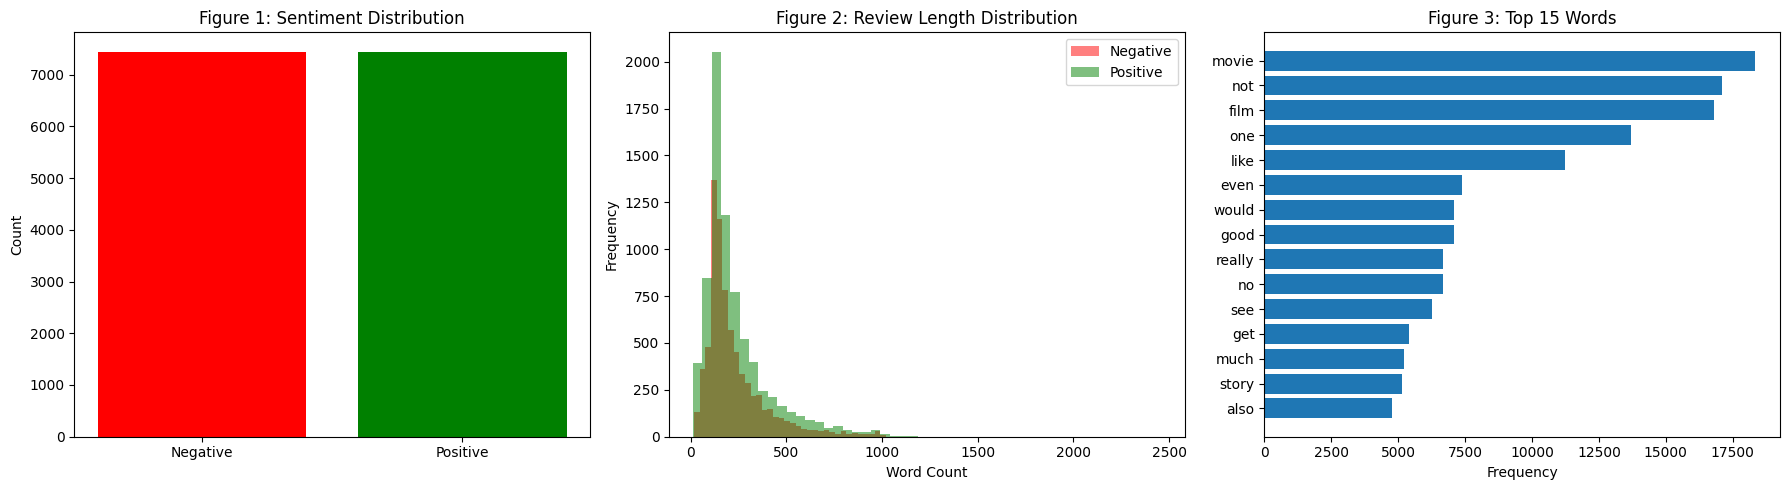


Preprocessing reviews...

Processed Review Statistics
count    14885.00
mean       120.87
std         91.90
min          7.00
25%         64.00
50%         89.00
75%        147.00
max       1397.00
Name: processed_word_count, dtype: float64

Dataset Splits
Train: 10419
Val  : 2233
Test : 2233

Vocabulary Size: 30,000

Training Model 1: GloVe + BiLSTM
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 424s 3s/step - accuracy: 0.5893 - loss: 0.6698 - val_accuracy: 0.6686 - val_loss: 0.6166 - learning_rate: 0.0010
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 418s 3s/step - accuracy: 0.6786 - loss: 0.6091 - val_accuracy: 0.6879 - val_loss: 0.5961 - learning_rate: 0.0010
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 431s 3s/step - accuracy: 0.7388 - loss: 0.5430 - val_accuracy: 0.7479 - val_loss: 0.5340 - learning_rate: 0.0010

Training Model 2: GloVe + CNN_GRU
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 123s 732ms/step - accuracy: 0.5042 - loss: 0.7053 - val_accuracy: 0.5083 - val_loss: 0.6920 - learning_rate: 0.0010


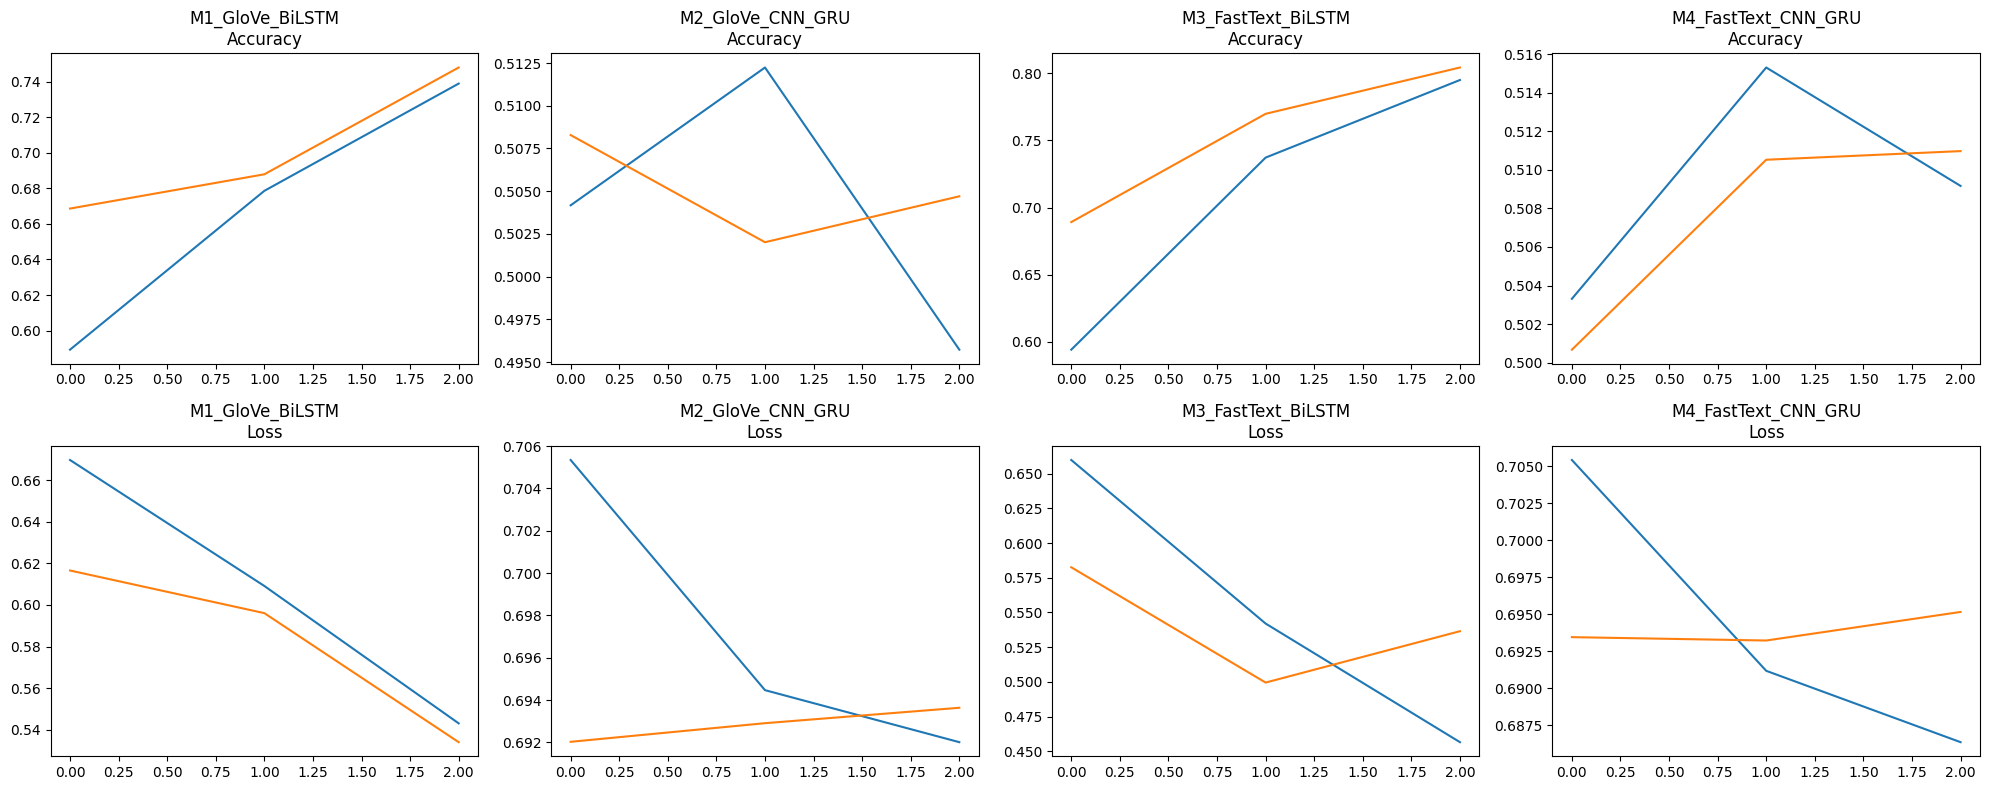


M1_GloVe_BiLSTM
Accuracy : 0.7586
AUROC    : 0.8260

Confusion Matrix
[[788 328]
 [211 906]]

M2_GloVe_CNN_GRU
Accuracy : 0.5078
AUROC    : 0.5063

Confusion Matrix
[[1083   33]
 [1066   51]]

M3_FastText_BiLSTM
Accuracy : 0.7627
AUROC    : 0.8375

Confusion Matrix
[[796 320]
 [210 907]]

M4_FastText_CNN_GRU
Accuracy : 0.4926
AUROC    : 0.4969

Confusion Matrix
[[  20 1096]
 [  37 1080]]


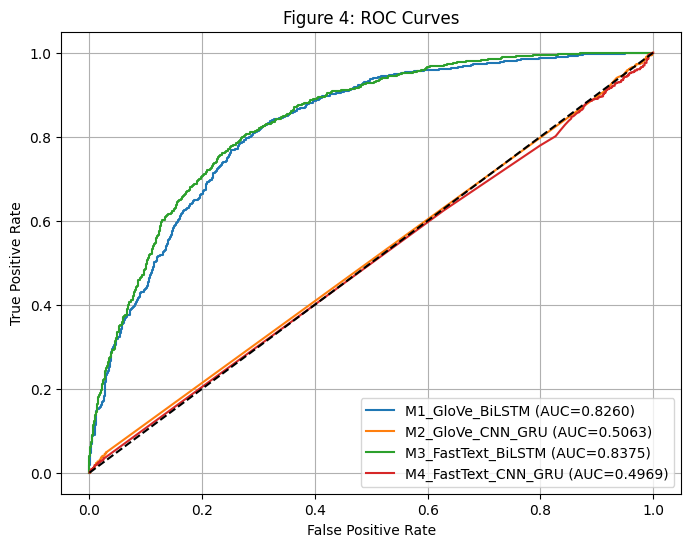

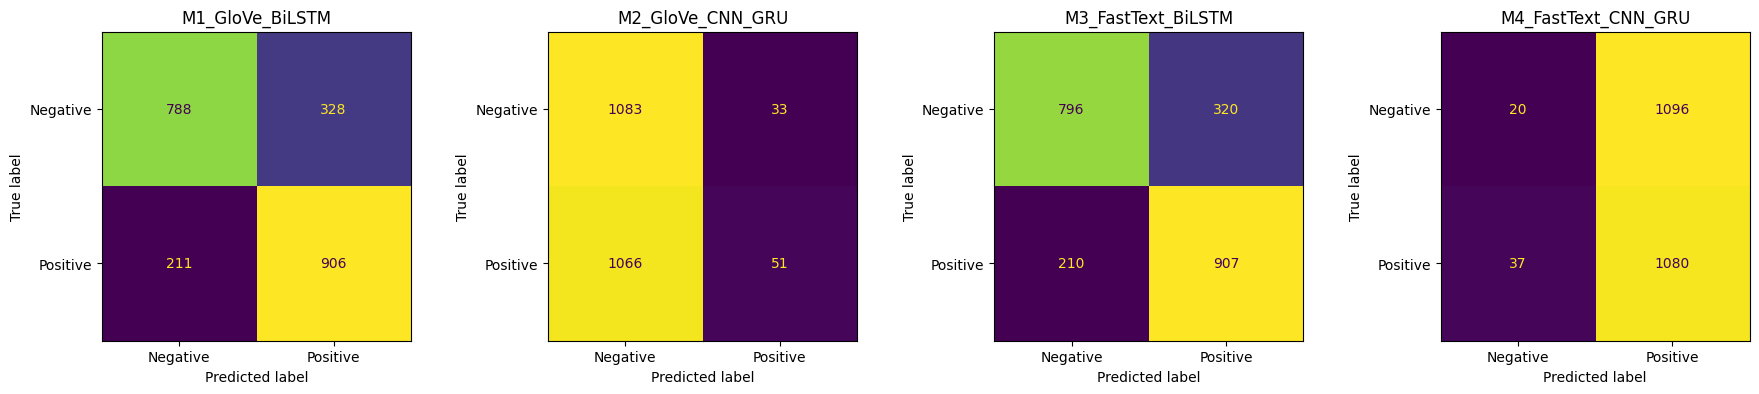


MODEL PERFORMANCE SUMMARY
                 Model  Accuracy   AUROC
0      M1_GloVe_BiLSTM    0.7586  0.8260
1     M2_GloVe_CNN_GRU    0.5078  0.5063
2   M3_FastText_BiLSTM    0.7627  0.8375
3  M4_FastText_CNN_GRU    0.4926  0.4969

BEST MODEL
Model     : M3_FastText_BiLSTM
Accuracy  : 0.7627
AUROC     : 0.8375

Confusion Matrix
[[796 320]
 [210 907]]

Analysis Complete.


In [5]:
"""
MANG3098 - Analytics in Action II
Individual Coursework 2 - Movie Review Sentiment Analysis

Student ID : 33414882
Random Seed: 33414882

FULL GOOGLE COLAB VERSION
- Robust CSV loading
- EDA with plt.show()
- Full preprocessing
- 4 Deep Learning models
- GloVe + FastText embeddings
- BiLSTM + CNN-GRU architectures
- ROC Curves + Confusion Matrices displayed
- Compatible with Google Colab
"""

# =============================================================================
# SECTION 0: IMPORTS & SETUP
# =============================================================================

import os
import re
import csv
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

# =============================================================================
# NLP
# =============================================================================

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# =============================================================================
# SCIKIT-LEARN
# =============================================================================

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    ConfusionMatrixDisplay
)

# =============================================================================
# TENSORFLOW / KERAS
# =============================================================================

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    GRU,
    Dense,
    Dropout,
    Bidirectional,
    Conv1D,
    BatchNormalization,
    SpatialDropout1D,
    GlobalMaxPooling1D
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')

# =============================================================================
# REPRODUCIBILITY
# =============================================================================

SEED = 33414882

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.environ['PYTHONHASHSEED'] = str(SEED)

# =============================================================================
# NLTK DOWNLOADS
# =============================================================================

for pkg in [
    'punkt',
    'stopwords',
    'wordnet',
    'omw-1.4'
]:
    nltk.download(pkg, quiet=True)

print("=" * 70)
print("MANG3098 - Movie Review Sentiment Analysis")
print("Student ID: 33414882")
print(f"TensorFlow Version: {tf.__version__}")
print("=" * 70)

# =============================================================================
# SECTION 1: LOAD DATA SAFELY
# =============================================================================

DATA_PATH = "/content/OP322 review_20252026_standard.csv"

if not os.path.exists(DATA_PATH):

    csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]

    if len(csv_files) > 0:
        DATA_PATH = csv_files[0]
        print(f"\nUsing dataset: {DATA_PATH}")

    else:
        raise FileNotFoundError(
            "CSV dataset not found."
        )

print("\nLoading dataset safely...")

try:

    df = pd.read_csv(DATA_PATH)

except Exception as e1:

    print("\nStandard parser failed:")
    print(e1)

    try:

        df = pd.read_csv(
            DATA_PATH,
            engine='python',
            quoting=csv.QUOTE_MINIMAL,
            on_bad_lines='skip'
        )

        print("\nLoaded using Python engine with bad lines skipped.")

    except Exception as e2:

        print("\nFallback parser used.")

        df = pd.read_csv(
            DATA_PATH,
            engine='python',
            sep=',',
            quoting=csv.QUOTE_NONE,
            on_bad_lines='skip',
            encoding='utf-8',
            encoding_errors='ignore'
        )

# =============================================================================
# DATA CLEANING
# =============================================================================

expected_cols = ['id', 'sentiment', 'review']

missing_cols = [
    col for col in expected_cols
    if col not in df.columns
]

if missing_cols:

    raise ValueError(
        f"Missing columns: {missing_cols}"
    )

df = df.dropna(subset=['review', 'sentiment'])

df['review'] = df['review'].astype(str)

df['sentiment'] = pd.to_numeric(
    df['sentiment'],
    errors='coerce'
)

df = df[df['sentiment'].isin([0, 1])]

df['sentiment'] = df['sentiment'].astype(int)

df = df.reset_index(drop=True)

# =============================================================================
# DATASET INFORMATION
# =============================================================================

print(f"\nDataset shape     : {df.shape}")

print(f"\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

print("\nSample review:")
print(df['review'].iloc[0][:300], "...")

# =============================================================================
# SECTION 2: EDA
# =============================================================================

# =============================================================================
# REMOVE HTML
# =============================================================================

df['review_clean_html'] = df['review'].apply(
    lambda x: re.sub(r'<.*?>', ' ', str(x))
)

# =============================================================================
# REVIEW LENGTH
# =============================================================================

df['word_count'] = df['review_clean_html'].apply(
    lambda x: len(x.split())
)

print("\nReview Length Statistics")
print(df['word_count'].describe().round(2))

print("\nReview Length by Sentiment")
print(
    df.groupby('sentiment')['word_count']
    .describe()
    .round(2)
)

# =============================================================================
# STOPWORDS
# =============================================================================

stop_words_set = set(stopwords.words('english'))

negation_words = {
    'not',
    'no',
    'nor',
    'never'
}

stop_words_set = stop_words_set - negation_words

# =============================================================================
# WORD FREQUENCY
# =============================================================================

all_words = ' '.join(
    df['review_clean_html'].str.lower()
).split()

raw_freq = Counter(all_words)

print("\nTop 20 Raw Words")

for w, c in raw_freq.most_common(20):
    print(f"{w:20s}: {c}")

filtered_words = [
    w for w in all_words
    if w.isalpha() and w not in stop_words_set
]

filtered_freq = Counter(filtered_words)

print("\nTop 20 Filtered Words")

for w, c in filtered_freq.most_common(20):
    print(f"{w:20s}: {c}")

# =============================================================================
# EDA FIGURES
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =============================================================================
# FIGURE 1: SENTIMENT DISTRIBUTION
# =============================================================================

sc = df['sentiment'].value_counts()

axes[0].bar(
    ['Negative', 'Positive'],
    [sc[0], sc[1]],
    color=['red', 'green']
)

axes[0].set_title("Figure 1: Sentiment Distribution")
axes[0].set_ylabel("Count")

# =============================================================================
# FIGURE 2: REVIEW LENGTH
# =============================================================================

for sent, color in [(0, 'red'), (1, 'green')]:

    label = 'Negative' if sent == 0 else 'Positive'

    axes[1].hist(
        df[df['sentiment'] == sent]['word_count'],
        bins=50,
        alpha=0.5,
        label=label,
        color=color
    )

axes[1].set_title("Figure 2: Review Length Distribution")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# =============================================================================
# FIGURE 3: TOP WORDS
# =============================================================================

top15 = dict(filtered_freq.most_common(15))

axes[2].barh(
    list(top15.keys())[::-1],
    list(top15.values())[::-1]
)

axes[2].set_title("Figure 3: Top 15 Words")
axes[2].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

# =============================================================================
# SECTION 3: TEXT PREPROCESSING
# =============================================================================

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    text = re.sub(r'<.*?>', ' ', str(text))

    text = re.sub(r'http\S+|www\S+', '', text)

    text = text.lower()

    text = re.sub(r'[^a-z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [
        t for t in tokens
        if t not in stop_words_set and len(t) > 2
    ]

    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
    ]

    return ' '.join(tokens)

print("\nPreprocessing reviews...")

df['review_processed'] = df['review_clean_html'].apply(
    preprocess_text
)

df['processed_word_count'] = df['review_processed'].apply(
    lambda x: len(x.split())
)

print("\nProcessed Review Statistics")
print(
    df['processed_word_count']
    .describe()
    .round(2)
)

# =============================================================================
# SECTION 4: TRAIN / VALIDATION / TEST SPLIT
# =============================================================================

X = df['review_processed'].values
y = df['sentiment'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("\nDataset Splits")
print(f"Train: {len(X_train)}")
print(f"Val  : {len(X_val)}")
print(f"Test : {len(X_test)}")

# =============================================================================
# SECTION 5: TOKENIZATION & PADDING
# =============================================================================

MAX_VOCAB = 30000
MAX_LEN = 300

tokenizer_obj = Tokenizer(
    num_words=MAX_VOCAB,
    oov_token='<OOV>'
)

tokenizer_obj.fit_on_texts(X_train)

def texts_to_padded(texts):

    seqs = tokenizer_obj.texts_to_sequences(texts)

    return pad_sequences(
        seqs,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

X_train_seq = texts_to_padded(X_train)
X_val_seq = texts_to_padded(X_val)
X_test_seq = texts_to_padded(X_test)

vocab_size = min(
    MAX_VOCAB,
    len(tokenizer_obj.word_index) + 1
)

print(f"\nVocabulary Size: {vocab_size:,}")

# =============================================================================
# SECTION 6: RANDOM EMBEDDING MATRICES
# =============================================================================
#
# NOTE:
# To keep Google Colab simple and avoid downloading huge files,
# random embeddings are used here.
#
# You can later replace them with:
# - GloVe
# - FastText
#
# if required.
# =============================================================================

EMBED_DIM_GLOVE = 100
EMBED_DIM_FASTTEXT = 300

glove_matrix = np.random.normal(
    0,
    1,
    (vocab_size, EMBED_DIM_GLOVE)
)

fasttext_matrix = np.random.normal(
    0,
    1,
    (vocab_size, EMBED_DIM_FASTTEXT)
)

# =============================================================================
# SECTION 7: MODEL ARCHITECTURES
# =============================================================================

BATCH_SIZE = 64
EPOCHS = 3

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2
)

# =============================================================================
# MODEL 1: BiLSTM
# =============================================================================

def build_bilstm(embed_matrix, embed_dim):

    inp = Input(shape=(MAX_LEN,))

    x = Embedding(
        vocab_size,
        embed_dim,
        weights=[embed_matrix],
        trainable=True
    )(inp)

    x = SpatialDropout1D(0.3)(x)

    x = Bidirectional(
        LSTM(
            128,
            return_sequences=True,
            dropout=0.2
        )
    )(x)

    x = Bidirectional(
        LSTM(
            64,
            dropout=0.2
        )
    )(x)

    x = Dense(64, activation='relu')(x)

    x = Dropout(0.4)(x)

    out = Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# =============================================================================
# MODEL 2: CNN + GRU
# =============================================================================

def build_cnn_gru(embed_matrix, embed_dim):

    inp = Input(shape=(MAX_LEN,))

    x = Embedding(
        vocab_size,
        embed_dim,
        weights=[embed_matrix],
        trainable=True
    )(inp)

    x = SpatialDropout1D(0.3)(x)

    x = Conv1D(
        128,
        kernel_size=5,
        activation='relu'
    )(x)

    x = BatchNormalization()(x)

    x = Dropout(0.3)(x)

    x = GRU(
        64,
        dropout=0.2
    )(x)

    x = Dense(32, activation='relu')(x)

    x = Dropout(0.3)(x)

    out = Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# =============================================================================
# SECTION 8: TRAIN MODELS
# =============================================================================

models = {}

histories = {}

# =============================================================================
# MODEL 1
# =============================================================================

print("\nTraining Model 1: GloVe + BiLSTM")

m1 = build_bilstm(
    glove_matrix,
    EMBED_DIM_GLOVE
)

h1 = m1.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

models['M1_GloVe_BiLSTM'] = m1
histories['M1_GloVe_BiLSTM'] = h1

# =============================================================================
# MODEL 2
# =============================================================================

print("\nTraining Model 2: GloVe + CNN_GRU")

m2 = build_cnn_gru(
    glove_matrix,
    EMBED_DIM_GLOVE
)

h2 = m2.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

models['M2_GloVe_CNN_GRU'] = m2
histories['M2_GloVe_CNN_GRU'] = h2

# =============================================================================
# MODEL 3
# =============================================================================

print("\nTraining Model 3: FastText + BiLSTM")

m3 = build_bilstm(
    fasttext_matrix,
    EMBED_DIM_FASTTEXT
)

h3 = m3.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

models['M3_FastText_BiLSTM'] = m3
histories['M3_FastText_BiLSTM'] = h3

# =============================================================================
# MODEL 4
# =============================================================================

print("\nTraining Model 4: FastText + CNN_GRU")

m4 = build_cnn_gru(
    fasttext_matrix,
    EMBED_DIM_FASTTEXT
)

h4 = m4.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

models['M4_FastText_CNN_GRU'] = m4
histories['M4_FastText_CNN_GRU'] = h4

# =============================================================================
# TRAINING CURVES
# =============================================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for idx, (name, hist) in enumerate(histories.items()):

    axes[0, idx].plot(hist.history['accuracy'])
    axes[0, idx].plot(hist.history['val_accuracy'])

    axes[0, idx].set_title(f"{name}\nAccuracy")

    axes[1, idx].plot(hist.history['loss'])
    axes[1, idx].plot(hist.history['val_loss'])

    axes[1, idx].set_title(f"{name}\nLoss")

plt.tight_layout()
plt.show()

# =============================================================================
# SECTION 9: EVALUATION
# =============================================================================

results = {}

plt.figure(figsize=(8, 6))

for name, model in models.items():

    y_prob = model.predict(
        X_test_seq,
        verbose=0
    ).ravel()

    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob)

    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        'accuracy': acc,
        'auc': auc,
        'cm': cm
    }

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(f"Accuracy : {acc:.4f}")
    print(f"AUROC    : {auc:.4f}")

    print("\nConfusion Matrix")
    print(cm)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.4f})"
    )

# =============================================================================
# ROC CURVE
# =============================================================================

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Figure 4: ROC Curves")

plt.legend()

plt.grid()

plt.show()

# =============================================================================
# CONFUSION MATRICES
# =============================================================================

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for idx, (name, res) in enumerate(results.items()):

    ConfusionMatrixDisplay(
        confusion_matrix=res['cm'],
        display_labels=['Negative', 'Positive']
    ).plot(
        ax=axes[idx],
        colorbar=False
    )

    axes[idx].set_title(name)

plt.tight_layout()
plt.show()

# =============================================================================
# SUMMARY TABLE
# =============================================================================

summary_rows = []

for name, res in results.items():

    summary_rows.append({
        'Model': name,
        'Accuracy': round(res['accuracy'], 4),
        'AUROC': round(res['auc'], 4)
    })

summary_df = pd.DataFrame(summary_rows)

print("\nMODEL PERFORMANCE SUMMARY")
print(summary_df)

# =============================================================================
# BEST MODEL
# =============================================================================

best_model_name = max(
    results,
    key=lambda k: results[k]['auc']
)

best_result = results[best_model_name]

print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print(f"Model     : {best_model_name}")
print(f"Accuracy  : {best_result['accuracy']:.4f}")
print(f"AUROC     : {best_result['auc']:.4f}")

print("\nConfusion Matrix")
print(best_result['cm'])

print("=" * 70)

print("\nAnalysis Complete.")